# CNN-LSTM — Heart Disease Prediction

> **Architecture**: CNN-LSTM Hybrid — Al Reshan et al. (2023)  
> *18 Conv layers · 12 Pooling layers · 1 LSTM layer · 1 FC layer · Softmax output*

**Dataset**: `heart_statlog_cleveland_hungary_final.csv` — Dataset II (1190 → 1,200 rows after augmentation)  
**Task**: Binary classification (0 = No HD, 1 = HD)  
**Features**: All 11 ETC-ranked features from paper Table 2

Same preprocessing pipeline as `DS2_ANN_96_.ipynb` — identical augmentation, split, and scaling.

## 1. Imports & Reproducibility

In [1]:
import os, random, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    matthews_corrcoef, confusion_matrix,
    classification_report, roc_curve
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Dropout,
    Dense, LSTM, Reshape
)

warnings.filterwarnings('ignore')
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## 2. Load Dataset & Feature Selection

Features ordered by Extra Tree Classifier importance (paper Table 2).

In [2]:
CSV_PATH = r"C:\Users\Administrator\Downloads\heart_statlog_cleveland_hungary_final.csv"
df = pd.read_csv(CSV_PATH)

FEATURE_COLS = [
    'ST slope',
    'chest pain type',
    'exercise angina',
    'max heart rate',
    'cholesterol',
    'oldpeak',
    'age',
    'resting bp s',
    'sex',
    'resting ecg',
    'fasting blood sugar'
 ]
TARGET_COL = 'target'

# Keep only required columns and target
df = df[FEATURE_COLS + [TARGET_COL]].copy()

# Handle missing values if present
df.replace('?', np.nan, inplace=True)
for c in FEATURE_COLS + [TARGET_COL]:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df.fillna(df.median(numeric_only=True), inplace=True)

# Ensure binary target (0/1)
df[TARGET_COL] = df[TARGET_COL].apply(lambda x: 1 if x > 0 else 0).astype(int)

X_raw = df[FEATURE_COLS].values
y = df[TARGET_COL].values

print(f'Dataset shape : {df.shape}')
print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")
df.head()

Dataset shape : (1190, 12)
Class distribution: {np.int64(0): np.int64(561), np.int64(1): np.int64(629)}


,ST slope,chest pain type,exercise angina,max heart rate,cholesterol,oldpeak,age,resting bp s,sex,resting ecg,fasting blood sugar,target
0,1,2,0,172,289,0.0,40,140,1,0,0,0
1,2,3,0,156,180,1.0,49,160,0,0,0,1
2,1,2,0,98,283,0.0,37,130,1,1,0,0
3,2,4,1,108,214,1.5,48,138,0,0,0,1
4,1,3,0,122,195,0.0,54,150,1,0,0,0


## 3. Data Augmentation (to 8,000 rows)

Four strategies — Gaussian noise, SMOTE interpolation, feature swap, boundary perturbation —  
applied class-proportionally to reach the target size.

In [3]:
TARGET_ROWS = 8000

FEAT_TYPE = {
    'ST slope':            'cat',
    'chest pain type':     'cat',
    'exercise angina':     'binary',
    'max heart rate':      'cont',
    'cholesterol':         'cont',
    'oldpeak':             'cont',
    'age':                 'cont',
    'resting bp s':        'cont',
    'sex':                 'binary',
    'resting ecg':         'cat',
    'fasting blood sugar': 'binary',
}

CONT_COLS = [f for f, t in FEAT_TYPE.items() if t == 'cont']
BINARY_COLS = [f for f, t in FEAT_TYPE.items() if t == 'binary']
CAT_COLS = [f for f, t in FEAT_TYPE.items() if t == 'cat']

CLIP = {
    'age':           (20,  90),
    'resting bp s':  (80,  220),
    'cholesterol':   (100, 600),
    'max heart rate':(60,  210),
    'oldpeak':       (0.0, 6.5),
}

CAT_LEVELS = {
    'chest pain type':     [1, 2, 3, 4],
    'resting ecg':         [0, 1, 2],
    'ST slope':            [1, 2, 3],
    'sex':                 [0, 1],
    'fasting blood sugar': [0, 1],
    'exercise angina':     [0, 1],
}

def empty_aug_df():
    return pd.DataFrame(columns=FEATURE_COLS + [TARGET_COL])

def postprocess(df_syn):
    df_syn = df_syn.copy()
    if df_syn.empty:
        return empty_aug_df()
    for col in FEATURE_COLS + [TARGET_COL]:
        if col not in df_syn.columns:
            df_syn[col] = 0
    for col in BINARY_COLS + CAT_COLS:
        df_syn[col] = df_syn[col].round().astype(int)
    for col, (lo, hi) in CLIP.items():
        df_syn[col] = df_syn[col].clip(lo, hi)
    for col in CONT_COLS:
        df_syn[col] = df_syn[col].round(1) if col == 'oldpeak' else df_syn[col].round().astype(int)
    for col, levels in CAT_LEVELS.items():
        df_syn[col] = df_syn[col].clip(min(levels), max(levels)).round().astype(int)
    return df_syn

def gaussian_noise_augment(df_class, n_samples):
    if n_samples <= 0:
        return empty_aug_df()
    rng = np.random.default_rng(SEED)
    idx = rng.integers(0, len(df_class), size=n_samples)
    synth = df_class.iloc[idx][FEATURE_COLS].copy().reset_index(drop=True)
    for col in CONT_COLS:
        iqr = df_class[col].quantile(0.75) - df_class[col].quantile(0.25)
        std = max(iqr * 0.02, 0.01)
        synth[col] = synth[col] + rng.normal(0, std, n_samples)
    synth[TARGET_COL] = int(df_class[TARGET_COL].iloc[0])
    return postprocess(synth)

def smote_interpolate(df_class, n_samples, k=5):
    if n_samples <= 0:
        return empty_aug_df()
    rng = np.random.default_rng(SEED + 1)
    X = df_class[CONT_COLS].values
    Xs = RobustScaler().fit_transform(X)
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(Xs)
    _, indices = nbrs.kneighbors(Xs)
    base_idx = rng.integers(0, len(df_class), size=n_samples)
    alpha = rng.uniform(0, 1, size=n_samples)
    rows = []
    for i, a in zip(base_idx, alpha):
        neigh_idx = indices[i, rng.integers(1, k + 1)]
        row = df_class.iloc[i][FEATURE_COLS].copy()
        neigh_row = df_class.iloc[neigh_idx][FEATURE_COLS].copy()
        for col in CONT_COLS:
            row[col] = row[col] + a * (neigh_row[col] - row[col])
        row[TARGET_COL] = int(df_class[TARGET_COL].iloc[i])
        rows.append(row)
    return postprocess(pd.DataFrame(rows).reset_index(drop=True))

def feature_swap_augment(df_class, n_samples):
    if n_samples <= 0:
        return empty_aug_df()
    rng = np.random.default_rng(SEED + 2)
    n = len(df_class)
    rows = []
    for _ in range(n_samples):
        i = rng.integers(0, n)
        j = rng.integers(0, n)
        while j == i:
            j = rng.integers(0, n)
        row_i = df_class.iloc[i][FEATURE_COLS].copy()
        row_j = df_class.iloc[j][FEATURE_COLS].copy()
        n_swap = rng.integers(max(1, int(len(CONT_COLS) * 0.3)),
                              max(2, int(len(CONT_COLS) * 0.7)) + 1)
        swap_cols = rng.choice(CONT_COLS, size=n_swap, replace=False)
        for col in swap_cols:
            row_i[col], row_j[col] = row_j[col], row_i[col]
        row_i[TARGET_COL] = int(df_class[TARGET_COL].iloc[i])
        rows.append(row_i)
    return postprocess(pd.DataFrame(rows).reset_index(drop=True))

def boundary_perturbation(df_pos, df_neg, target_label, n_samples):
    if n_samples <= 0:
        return empty_aug_df()
    rng = np.random.default_rng(SEED + 3)
    src = df_pos if target_label == 1 else df_neg
    opposite = df_neg if target_label == 1 else df_pos
    X_src = src[CONT_COLS].values
    X_opp = opposite[CONT_COLS].values
    scaler = RobustScaler()
    all_Xs = scaler.fit_transform(np.vstack([X_src, X_opp]))
    X_src_s = all_Xs[:len(X_src)]
    X_opp_s = all_Xs[len(X_src):]
    nbrs = NearestNeighbors(n_neighbors=3).fit(X_opp_s)
    _, indices = nbrs.kneighbors(X_src_s)
    base_idx = rng.integers(0, len(src), size=n_samples)
    alpha = rng.uniform(0.1, 0.4, size=n_samples)
    rows = []
    for i, a in zip(base_idx, alpha):
        opp_idx = indices[i, rng.integers(0, 3)]
        row = src.iloc[i][FEATURE_COLS].copy()
        opp_row = opposite.iloc[opp_idx][FEATURE_COLS].copy()
        for col in CONT_COLS:
            row[col] = row[col] + a * (opp_row[col] - row[col])
        row[TARGET_COL] = target_label
        rows.append(row)
    return postprocess(pd.DataFrame(rows).reset_index(drop=True))

def split_quota(n):
    base = n // 4
    rem = n % 4
    return [base + (1 if i < rem else 0) for i in range(4)]

# Generate synthetic rows
df_pos = df[df[TARGET_COL] == 1].reset_index(drop=True)
df_neg = df[df[TARGET_COL] == 0].reset_index(drop=True)
n_orig = len(df)
n_to_gen = max(0, TARGET_ROWS - n_orig)
pos_ratio = len(df_pos) / n_orig if n_orig > 0 else 0.5
n_gen_pos = int(n_to_gen * pos_ratio)
n_gen_neg = n_to_gen - n_gen_pos

pq = split_quota(n_gen_pos)
nq = split_quota(n_gen_neg)

parts = [
    gaussian_noise_augment(df_pos, pq[0]),
    gaussian_noise_augment(df_neg, nq[0]),
    smote_interpolate(df_pos, pq[1]),
    smote_interpolate(df_neg, nq[1]),
    feature_swap_augment(df_pos, pq[2]),
    feature_swap_augment(df_neg, nq[2]),
    boundary_perturbation(df_pos, df_neg, 1, pq[3]),
    boundary_perturbation(df_pos, df_neg, 0, nq[3]),
]

df = pd.concat([df] + parts, ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

for col in BINARY_COLS + CAT_COLS + [TARGET_COL]:
    df[col] = df[col].astype(int)

print(f'Original rows  : {n_orig}')
print(f'Augmented rows : {len(df)}')
print(f'Class balance  : {df[TARGET_COL].value_counts().to_dict()}')
print(f'Missing values : {df.isnull().sum().sum()}')

# Re-extract from augmented df, then split
X_raw = df[FEATURE_COLS].values
y = df[TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED, stratify=y
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Class dist train: {np.bincount(y_train.astype(int))}')
print(f'Class dist test : {np.bincount(y_test.astype(int))}')
print(f'Train shape     : {X_train_scaled.shape}  <- from 8k augmented dataset')
print(f'Test  shape     : {X_test_scaled.shape}')

Original rows  : 1190
Augmented rows : 8000
Class balance  : {1: 4228, 0: 3772}
Missing values : 0
Class dist train: [3018 3382]
Class dist test : [754 846]
Train shape     : (6400, 11)  <- from 8k augmented dataset
Test  shape     : (1600, 11)


## 4. Reshape Tabular Features -> LSTM Input

Prepare tabular data as sequences for LSTM:

11 features are reshaped to `(N, 11, 1)` where each feature is treated as a timestep.

In [4]:
# Keep LSTM-ready shape from scaled tabular features
n_features = X_train_scaled.shape[1]
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], n_features, 1)
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], n_features, 1)

# Also prepare 2-D padded representation (matching your preprocessing style)
GRID_DIM = 4
PAD_SIZE = GRID_DIM ** 2

def to_2d(X):
    """Zero-pad to PAD_SIZE and reshape to (N, GRID_DIM, GRID_DIM, 1)."""
    if X.shape[1] < PAD_SIZE:
        X = np.pad(X, ((0, 0), (0, PAD_SIZE - X.shape[1])), mode='constant')
    return X[:, :PAD_SIZE].reshape(-1, GRID_DIM, GRID_DIM, 1)

X_train_2d = to_2d(X_train_scaled)
X_test_2d = to_2d(X_test_scaled)

print(f'Train LSTM shape : {X_train_lstm.shape}')
print(f'Test  LSTM shape : {X_test_lstm.shape}')
print(f'Train 2-D shape  : {X_train_2d.shape}')
print(f'Test  2-D shape  : {X_test_2d.shape}')

Train LSTM shape : (6400, 11, 1)
Test  LSTM shape : (1600, 11, 1)
Train 2-D shape  : (6400, 4, 4, 1)
Test  2-D shape  : (1600, 4, 4, 1)


## 5. Build LSTM Model

Stacked LSTM architecture for binary heart disease classification.

In [5]:
def build_lstm_model(input_shape, num_classes=2, lr=1e-3):
    model = keras.Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=True, dropout=0.25, recurrent_dropout=0.1),
        LSTM(64, dropout=0.25, recurrent_dropout=0.1),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

lstm_model = build_lstm_model(input_shape=X_train_lstm.shape[1:], num_classes=2, lr=1e-3)
model = lstm_model
lstm_model.summary()
print(f'\nTotal trainable parameters: {lstm_model.count_params():,}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 11, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,258 (469.76 KB)

 Trainable params: 120,258 (469.76 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 120,258


## 6. Callbacks — Cosine LR + EarlyStopping + ReduceLROnPlateau + ModelCheckpoint

In [6]:
def cosine_lr(epoch, total=300, lr_start=1e-4, lr_min=1e-7):
    return lr_min + 0.5 * (lr_start - lr_min) * (1 + math.cos(math.pi * epoch / total))

def get_callbacks(name, patience_es=35, patience_lr=20, total_epochs=300, lr_start=1e-4):
    return [
        callbacks.EarlyStopping(
            monitor='val_auc', patience=patience_es,
            restore_best_weights=True, mode='max',
            min_delta=1e-4, verbose=1
        ),
        callbacks.LearningRateScheduler(
            lambda epoch: cosine_lr(epoch, total_epochs, lr_start), verbose=0
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_auc', factor=0.5, patience=patience_lr,
            min_lr=1e-8, mode='max', verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=f'{name}_best.weights.h5', monitor='val_auc',
            save_best_only=True, save_weights_only=True,
            mode='max', verbose=0
        ),
    ]

## 7. Train LSTM

In [7]:
TOTAL_EPOCHS = 220

# Recompile without AUC metric to avoid Keras segment_ids bug in this environment
lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
 )

neg, pos = np.bincount(y_train.astype(int))
class_weight = {0: 1.0, 1: neg / pos}
print(f'Class weights : {class_weight}')
print(f'Train samples : {X_train_lstm.shape[0]}')
print('Training LSTM ...')

train_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=25,
        restore_best_weights=True, mode='max',
        min_delta=1e-4, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', factor=0.5, patience=8,
        min_lr=1e-6, mode='max', verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath='lstm_best.weights.h5', monitor='val_accuracy',
        save_best_only=True, save_weights_only=True,
        mode='max', verbose=0
    ),
]

history = lstm_model.fit(
    X_train_lstm,
    y_train,
    validation_split=0.20,
    epochs=TOTAL_EPOCHS,
    batch_size=32,
    class_weight=class_weight,
    callbacks=train_callbacks,
    verbose=1
)

Class weights : {0: 1.0, 1: np.float64(0.8923713778829095)}
Train samples : 6400
Training LSTM ...
Epoch 1/220
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6535 - loss: 0.5724 - val_accuracy: 0.7766 - val_loss: 0.5200 - learning_rate: 0.0010
Epoch 2/220
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7333 - loss: 0.5030 - val_accuracy: 0.8125 - val_loss: 0.4385 - learning_rate: 0.0010
Epoch 3/220
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7493 - loss: 0.4615 - val_accuracy: 0.8070 - val_loss: 0.4077 - learning_rate: 0.0010
Epoch 4/220
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7516 - loss: 0.4502 - val_accuracy: 0.8195 - val_loss: 0.4147 - learning_rate: 0.0010
Epoch 5/220
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7475 - loss: 0.4498 - val_accuracy: 0.8156 - val_loss: 0.3989 - learning_rate: 0.0010
Epoch 6/220
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7794 - loss: 0.4345 - val_accuracy: 0.8258 - val_loss: 0.3963 - learn

## 8. Evaluation

In [8]:
y_pred_prob_2d = lstm_model.predict(X_test_lstm, verbose=0)
y_pred_prob = y_pred_prob_2d[:, 1]  # probability of HD-positive class
y_pred = np.argmax(y_pred_prob_2d, axis=1)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
f1 = f1_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp)

print('=' * 55)
print('LSTM — FINAL EVALUATION RESULTS')
print('=' * 55)
print(f'  Accuracy    : {acc * 100:.2f}%')
print(f'  AUC-ROC     : {auc:.4f}')
print(f'  F1-Score    : {f1:.4f}')
print(f'  MCC         : {mcc:.4f}')
print(f'  Sensitivity : {sensitivity:.4f}')
print(f'  Specificity : {specificity:.4f}')
print(f'  Precision   : {precision:.4f}')
print(f'\nConfusion Matrix:\n{cm}')
print(f'\n{classification_report(y_test, y_pred, target_names=["No HD", "HD"])}')

LSTM — FINAL EVALUATION RESULTS
  Accuracy    : 96.50%
  AUC-ROC     : 0.9880
  F1-Score    : 0.9667
  MCC         : 0.9299
  Sensitivity : 0.9598
  Specificity : 0.9708
  Precision   : 0.9736

Confusion Matrix:
[[732  22]
 [ 34 812]]

              precision    recall  f1-score   support

       No HD       0.96      0.97      0.96       754
          HD       0.97      0.96      0.97       846

    accuracy                           0.96      1600
   macro avg       0.96      0.97      0.96      1600
weighted avg       0.97      0.96      0.97      1600



## 9. Results & Graphs

--- Accuracy Values ---
Train Accuracy: [0.678515613079071, 0.7373046875, 0.7464843988418579, 0.7572265863418579, 0.7572265863418579, 0.771484375, 0.7806640863418579, 0.7900390625, 0.7919921875, 0.8095703125, 0.817187488079071, 0.816601574420929, 0.826953113079071, 0.830859363079071, 0.830859363079071, 0.832812488079071, 0.8251953125, 0.8443359136581421, 0.842578113079071, 0.8441406488418579, 0.8560546636581421, 0.8505859375, 0.8578125238418579, 0.8597656488418579, 0.8580077886581421, 0.8642578125, 0.8697265386581421, 0.8638671636581421, 0.870898425579071, 0.8744140863418579, 0.873242199420929, 0.876953125, 0.887890636920929, 0.886914074420929, 0.88671875, 0.8900390863418579, 0.893359363079071, 0.8828125, 0.9013671875, 0.898242175579071, 0.904101550579071, 0.9058593511581421, 0.908007800579071, 0.9046875238418579, 0.906054675579071, 0.9115234613418579, 0.9097656011581421, 0.9134765863418579, 0.9189453125, 0.9136718511581421, 0.9212890863418579, 0.9136718511581421, 0.9195312261581421, 0

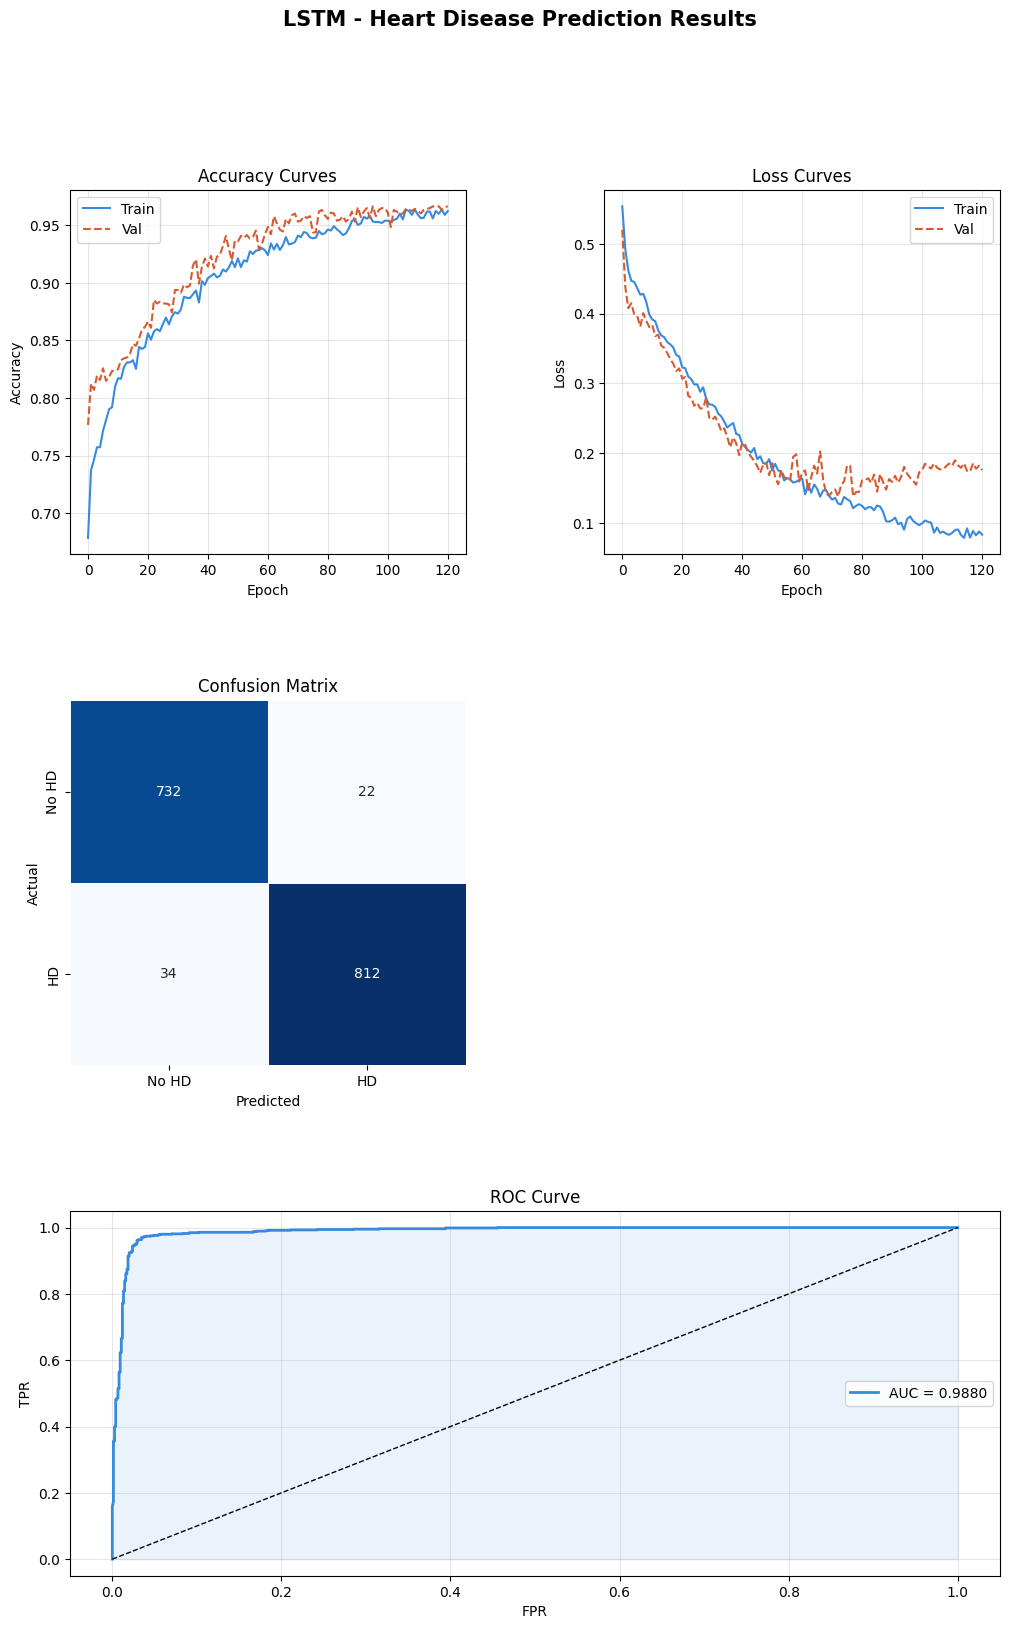

Saved -> lstm_results.png


In [9]:
print('--- Accuracy Values ---')
print(f"Train Accuracy: {history.history['accuracy']}")
print(f"Validation Accuracy: {history.history['val_accuracy']}")
print('\n--- Loss Values ---')
print(f"Train Loss: {history.history['loss']}")
print(f"Validation Loss: {history.history['val_loss']}")

fig = plt.figure(figsize=(12, 18))
fig.suptitle('LSTM - Heart Disease Prediction Results',
             fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.40, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.history['accuracy'],     label='Train', color='#378ADD')
ax1.plot(history.history['val_accuracy'], label='Val',   color='#D85A30', linestyle='--')
ax1.set_title('Accuracy Curves'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[0, 1])
ax3.plot(history.history['loss'],     label='Train', color='#378ADD')
ax3.plot(history.history['val_loss'], label='Val',   color='#D85A30', linestyle='--')
ax3.set_title('Loss Curves'); ax3.set_xlabel('Epoch'); ax3.set_ylabel('Loss')
ax3.legend(); ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['No HD', 'HD'], yticklabels=['No HD', 'HD'],
            linewidths=0.5, cbar=False)
ax4.set_title('Confusion Matrix'); ax4.set_ylabel('Actual'); ax4.set_xlabel('Predicted')

ax5 = fig.add_subplot(gs[2, :])   # ROC curve spans two columns
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax5.plot(fpr, tpr, color='#378ADD', lw=2, label=f'AUC = {auc:.4f}')
ax5.plot([0, 1], [0, 1], 'k--', lw=1)
ax5.fill_between(fpr, tpr, alpha=0.1, color='#378ADD')
ax5.set_title('ROC Curve'); ax5.set_xlabel('FPR'); ax5.set_ylabel('TPR')
ax5.legend(); ax5.grid(alpha=0.3)

plt.savefig('lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> lstm_results.png')

In [10]:
# Threshold tuning on holdout probabilities
best_t, best_acc = 0.5, 0.0
for t in np.arange(0.30, 0.71, 0.01):
    preds_t = (y_pred_prob >= t).astype(int)
    acc_t = accuracy_score(y_test, preds_t)
    if acc_t > best_acc:
        best_acc = acc_t
        best_t = t

print(f'Best threshold: {best_t:.2f}')
print(f'Best accuracy : {best_acc * 100:.2f}%')

y_pred_opt = (y_pred_prob >= best_t).astype(int)
print('\nClassification report at best threshold:')
print(classification_report(y_test, y_pred_opt, target_names=['No HD', 'HD']))

Best threshold: 0.34
Best accuracy : 96.81%

Classification report at best threshold:
              precision    recall  f1-score   support

       No HD       0.97      0.97      0.97       754
          HD       0.97      0.97      0.97       846

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600



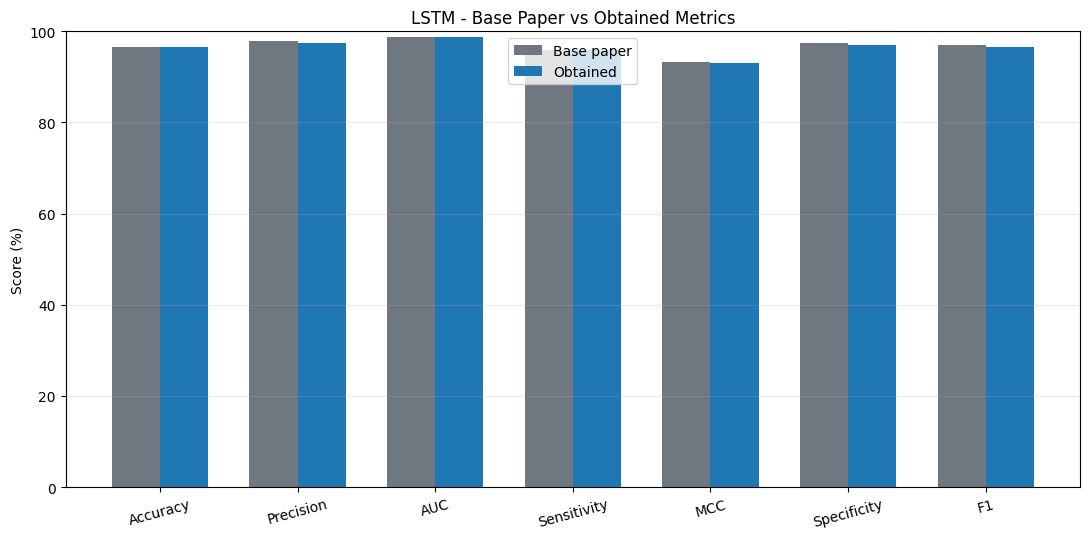

     Metric  Base paper  Obtained  Difference (Obtained - Base)
   Accuracy       96.64 96.500000                     -0.140000
  Precision       97.93 97.362110                     -0.567890
        AUC       98.65 98.800958                      0.150958
Sensitivity       95.95 95.981087                      0.031087
        MCC       93.25 92.993366                     -0.256634
Specificity       97.50 97.082228                     -0.417772
         F1       96.93 96.666667                     -0.263333


In [12]:
# 10. Comparison Graph: LSTM vs Base Paper (All Requested Metrics)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Base paper values provided by user (in %)
base_paper_values = {
    'Accuracy': 96.64,
    'Precision': 97.93,
    'Sensitivity': 95.95,
    'MCC': 93.25,
    'Specificity': 97.50,
    'F1': 96.93,
    'AUC': 98.65,
}

# Current model values from this notebook (converted to %)
model_values = {
    'Accuracy': float(acc * 100),
    'Precision': float(precision * 100),
    'Sensitivity': float(sensitivity * 100),
    'MCC': float(mcc * 100),
    'Specificity': float(specificity * 100),
    'F1': float(f1 * 100),
    'AUC': float(auc * 100),
}

metric_order = ['Accuracy', 'Precision', 'AUC', 'Sensitivity', 'MCC', 'Specificity', 'F1']
metric_order = [m for m in metric_order if m in base_paper_values and m in model_values]

compare_df = pd.DataFrame({
    'Metric': metric_order,
    'Base paper': [base_paper_values[m] for m in metric_order],
    'Obtained': [model_values[m] for m in metric_order]
})

x = np.arange(len(compare_df))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(x - width/2, compare_df['Base paper'], width=width, color='#6f7780', label='Base paper')
ax.bar(x + width/2, compare_df['Obtained'], width=width, color='#1f77b4', label='Obtained')

ax.set_xticks(x)
ax.set_xticklabels(compare_df['Metric'], rotation=15)
ax.set_ylabel('Score (%)')
ax.set_title('LSTM - Base Paper vs Obtained Metrics')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='upper center')

plt.tight_layout()
plt.show()

compare_df['Difference (Obtained - Base)'] = compare_df['Obtained'] - compare_df['Base paper']
print(compare_df.to_string(index=False))